In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
df = pd.read_csv("/content/drive/MyDrive/online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [40]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
# Remove missing values
df = df.dropna(subset=["CustomerID"])
df.shape

(406829, 8)

In [ ]:
# Convert Date Column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [ ]:
# Create Revenue Column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
# Total revenue of the business
total_revenue = df["Revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 8300065.814000001


In [ ]:
# revenue by country
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_revenue.head(10)

,Revenue
Country,
United Kingdom,6767873.394
Netherlands,284661.540
EIRE,250285.220
Germany,221698.210
France,196712.840
Australia,137077.270
Switzerland,55739.400
Spain,54774.580
Belgium,40910.960


Text(0, 0.5, 'Revenue')

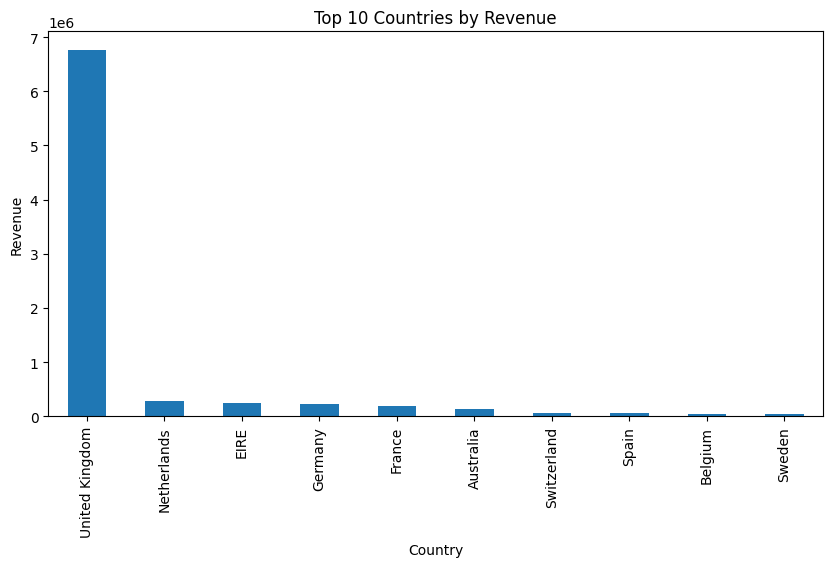

In [ ]:
# Visualization
country_revenue.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

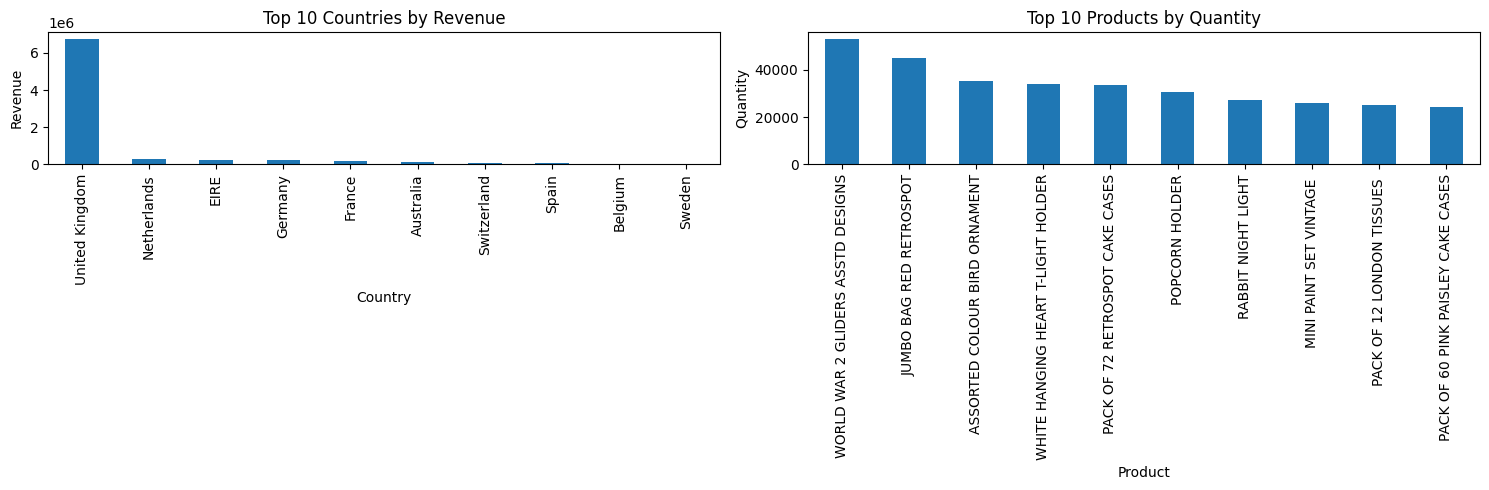

In [ ]:
# Visualization Using Subplots

# Top 10 countries by revenue
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

# Top 10 products by quantity
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

# Create subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

# Plot 1: Country revenue
top_countries.plot(kind="bar", ax=ax1)
ax1.set_title("Top 10 Countries by Revenue")
ax1.set_xlabel("Country")
ax1.set_ylabel("Revenue")

# Plot 2: Top products
top_products.plot(kind="bar", ax=ax2)
ax2.set_title("Top 10 Products by Quantity")
ax2.set_xlabel("Product")
ax2.set_ylabel("Quantity")

plt.tight_layout()
plt.show()

In [ ]:
# Top Selling Products
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
top_products.head(10)

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53215
JUMBO BAG RED RETROSPOT,45066
ASSORTED COLOUR BIRD ORNAMENT,35314
WHITE HANGING HEART T-LIGHT HOLDER,34147
PACK OF 72 RETROSPOT CAKE CASES,33409
POPCORN HOLDER,30504
RABBIT NIGHT LIGHT,27094
MINI PAINT SET VINTAGE,25880
PACK OF 12 LONDON TISSUES,25321


In [ ]:
# Monthly Sales trend
df["Month"] = df["InvoiceDate"].dt.month
monthly_sales = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()
monthly_sales.head()

,Revenue
InvoiceDate,
2010-12,554604.020
2011-01,475074.380
2011-02,436546.150
2011-03,579964.610
2011-04,426047.851


Text(0, 0.5, 'Revenue')

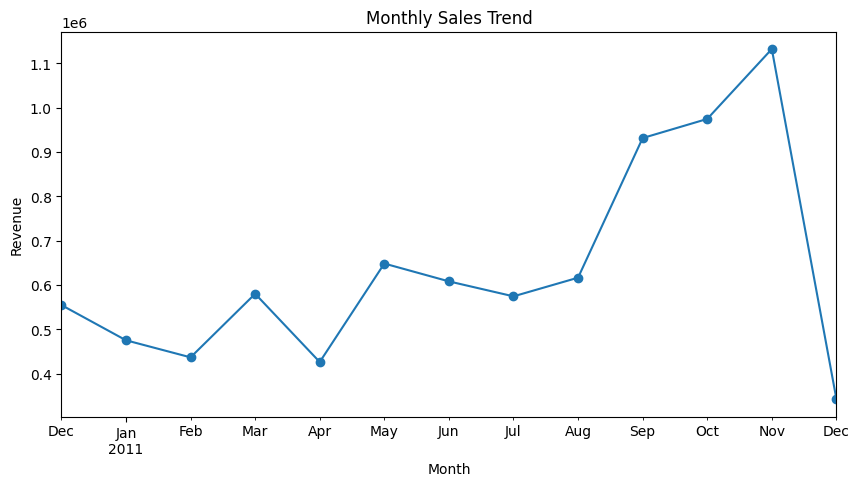

In [ ]:
# Monthly Sales Graph
monthly_sales.plot(kind="line", marker="o",figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")


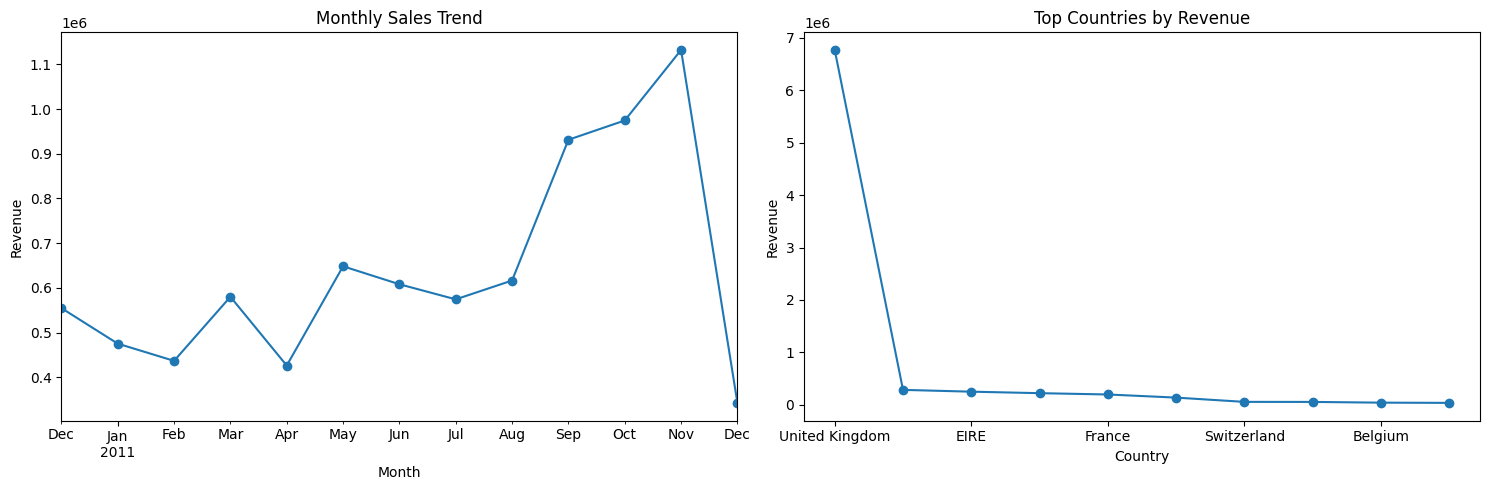

In [ ]:
#  Monthly Sales Graph Using Subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

# Monthly sales trend
monthly_sales.plot(kind="line", marker="o", ax=ax1)
ax1.set_title("Monthly Sales Trend")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue")

# Country revenue
country_revenue.head(10).plot(kind="line", marker="o", ax=ax2)
ax2.set_title("Top Countries by Revenue")
ax2.set_xlabel("Country")
ax2.set_ylabel("Revenue")

plt.tight_layout()
plt.show()

Phase 2 - Customer segmentation (AI using K-Means)

In [ ]:
# Create Customer Data
customer_data = df.groupby("CustomerID").agg({
    "Revenue":"sum",
    "InvoiceNo":"count"
})
customer_data.head(10)

,Revenue,InvoiceNo
CustomerID,,
12346.0,0.00,2
12347.0,4310.00,182
12348.0,1797.24,31
12349.0,1757.55,73
12350.0,334.40,17
12352.0,1545.41,95
12353.0,89.00,4
12354.0,1079.40,58
12355.0,459.40,13


In [ ]:
# Rename columns
customer_data.columns = ["TotalSpends", "PurchaseFrequency"]
customer_data.head(10)

,TotalSpends,PurchaseFrequency
CustomerID,,
12346.0,0.00,2
12347.0,4310.00,182
12348.0,1797.24,31
12349.0,1757.55,73
12350.0,334.40,17
12352.0,1545.41,95
12353.0,89.00,4
12354.0,1079.40,58
12355.0,459.40,13


In [ ]:
# Normalize Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_data)
scaled_data

array([[-0.23100099, -0.3917197 ],
       [ 0.29343167,  0.38265697],
       [-0.01231622, -0.26695902],
       ...,
       [-0.20951263, -0.34439668],
       [ 0.02390005,  2.85205812],
       [-0.00744423, -0.0991774 ]])

In [ ]:
# Apply K-Means Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

customer_data["Cluster"] = kmeans.fit_predict(scaled_data)
customer_data.head(10)

,TotalSpends,PurchaseFrequency,Cluster
CustomerID,,,
12346.0,0.00,2,0
12347.0,4310.00,182,0
12348.0,1797.24,31,0
12349.0,1757.55,73,0
12350.0,334.40,17,0
12352.0,1545.41,95,0
12353.0,89.00,4,0
12354.0,1079.40,58,0
12355.0,459.40,13,0


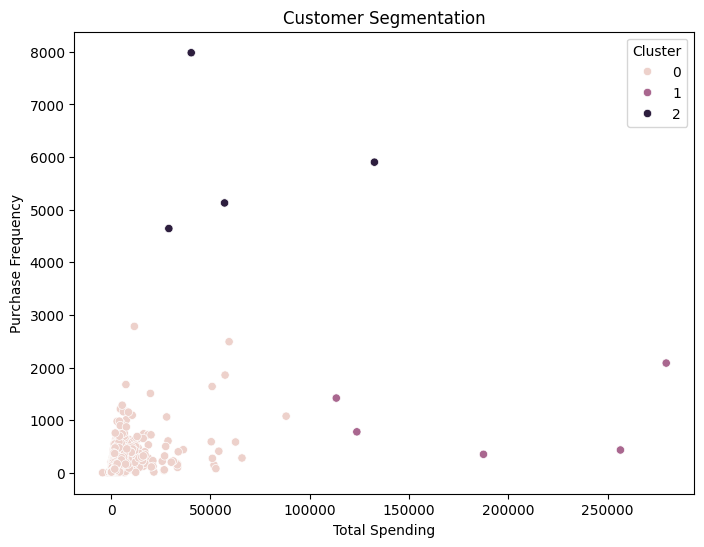

In [ ]:
# visualize Customer Segments
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=customer_data["TotalSpends"],
    y=customer_data["PurchaseFrequency"],
    hue=customer_data["Cluster"])
plt.title("Customer Segmentation")
plt.xlabel("Total Spending")
plt.ylabel("Purchase Frequency")
plt.show()

In [ ]:
# Prepare Monthly Data for ML
monthly_sales = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()

monthly_sales =monthly_sales.reset_index()

monthly_sales["MonthNumber"] = range(1, len(monthly_sales) + 1)
monthly_sales.head(10)

,InvoiceDate,Revenue,MonthNumber
0,2010-12,554604.020,1
1,2011-01,475074.380,2
2,2011-02,436546.150,3
3,2011-03,579964.610,4
4,2011-04,426047.851,5
5,2011-05,648251.080,6
6,2011-06,608013.160,7
7,2011-07,574238.481,8
8,2011-08,616368.000,9
9,2011-09,931440.372,10


In [ ]:
# Define Features(X) and Target(y)
X=monthly_sales[["MonthNumber"]]
y=monthly_sales["Revenue"]

X.head(), y.head()

(   MonthNumber
 0            1
 1            2
 2            3
 3            4
 4            5,
 0    554604.020
 1    475074.380
 2    436546.150
 3    579964.610
 4    426047.851
 Name: Revenue, dtype: float64)

In [ ]:
# Train the MOdel
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [ ]:
# Predict Future sales

future_months = np.array(range(len(monthly_sales)+1, len(monthly_sales)+7)).reshape(-1,1)

predictions = model.predict(future_months)

predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 851057.58973077,  881427.73096703,  911797.8722033 ,
        942168.01343956,  972538.15467582, 1002908.29591209])

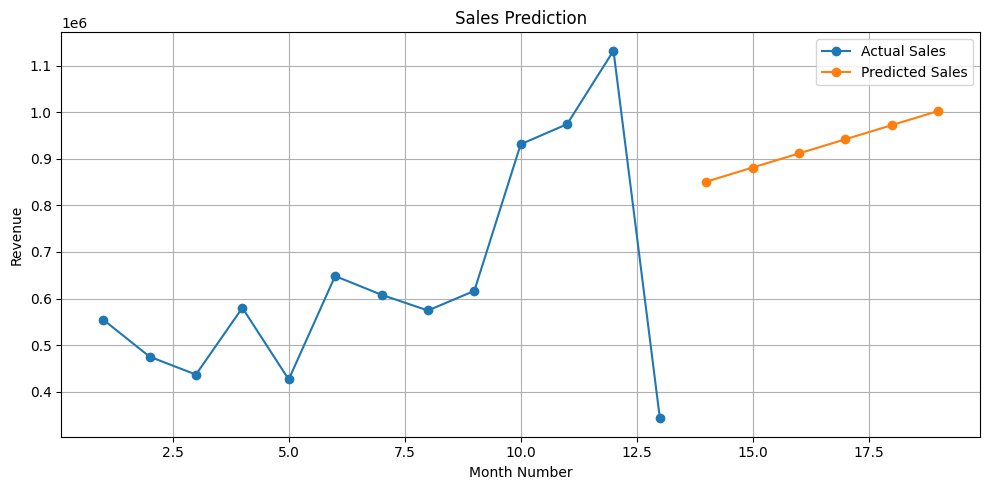

In [ ]:
# Plot Pridiction Graph
plt.figure(figsize=(10,5))

plt.plot(monthly_sales["MonthNumber"], y, label="Actual Sales", marker="o")

plt.plot(future_months, predictions, label="Predicted Sales", marker="o")

plt.title("Sales Prediction")
plt.xlabel("Month Number")
plt.ylabel("Revenue")

plt.legend()

plt.grid(True)        #grid lines
plt.tight_layout()    #spacing improve

plt.show()

Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
# Data Normalization (Scaling Data for Neural Network)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Scale input features
X_scaled = scaler.fit_transform(X)

# Scale target values
y_scaled = scaler.fit_transform(y.values.reshape(-1,1))

In [ ]:
# Build Deep Learning Model (Neural Network)
model_dl = models.Sequential([
    layers.Dense(64, activation='relu'),   # Hidden Layer 1
    layers.Dense(32, activation='relu'),   # Hidden Layer 2
    layers.Dense(1)                        # Output Layer
])


In [ ]:
# Compile Model
# Define optimizer and loss function
model_dl.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
# Model train
history = model_dl.fit(X_scaled, y_scaled, epochs=100, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1767
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1625
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1507
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1400
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1301
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1209
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1123
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1044
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0972
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0908
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0852
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0805
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0764
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0729
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0698
Epoch 16/100
1/1 ━━━━

In [ ]:
# Predict Future Sales using Deep Learning Model
future_scaled = scaler.transform(future_months)

dl_predictions = model_dl.predict(future_scaled)

print("Future Sales Prediction:")
print(dl_predictions)

prediction_table = pd.DataFrame({
    "Month": future_months.flatten(),
    "Predicted Sales": dl_predictions.flatten()
})

print(prediction_table)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Future Sales Prediction:
[[0.10599863]
 [0.10599855]
 [0.10599849]
 [0.10599842]
 [0.10599835]
 [0.10599829]]
   Month  Predicted Sales
0     14         0.105999
1     15         0.105999
2     16         0.105998
3     17         0.105998
4     18         0.105998
5     19         0.105998


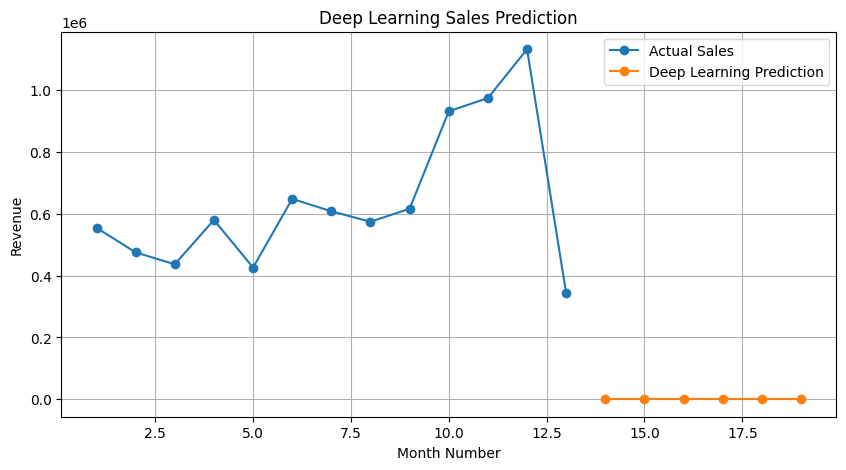

In [ ]:
# Visualization of Deep Learning Prediction

plt.figure(figsize=(10,5))

# Actual Sales Data
plt.plot(monthly_sales["MonthNumber"], y, label="Actual Sales", marker="o")

# Deep Learning Predicted Sales
plt.plot(future_months, dl_predictions, label="Deep Learning Prediction", marker="o")

plt.legend()
plt.title("Deep Learning Sales Prediction")
plt.xlabel("Month Number")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

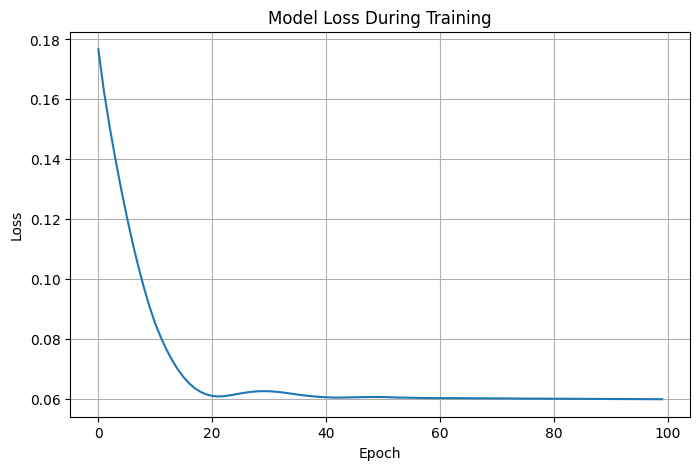

In [ ]:
# Deep Learning Training Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.title("Model Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()